# Klasifikacija statusa stroja

Na osnovu podataka u datasetu, potrebno je predvidjeti status stroja. Model treba vratiti je li stroj u statusu:
- OK
- WARNING
- FAILURE

## Datasets
- Dataset za treniranje modela - 13_dataset_proizvodna_kontrola.csv
- Dataset za provjeru modela - 13_novi_podaci_za_predikciju.csv

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

pd.set_option('display.float_format', '{:,.2f}'.format)

In [11]:
# df = pd.read_csv('data/13_dataset_proizvodna_kontrola.csv', on_bad_lines='skip')
df = pd.read_csv('data/13_dataset_proizvodna_kontrola.csv', sep=';')
df.head(7)

,record_id,machine_type,shift,operator_level,maintenance_done_recently,temperature_c,pressure_bar,vibration_mm_s,current_a,runtime_hours,humidity_pct,production_rate_units_h,defect_count_last_hour,days_since_maintenance,machine_status
0,100528,Conveyor,Morning,Intermediate,No,54.58,6.54,error,10.34,643.8,46.8,"121,9",0,14,OK
1,100739,Pump,Morning,Intermediate,Yes,74.41,8.11,4.76,20.9,828.4,59.9,92.8,3,23,FAILURE
2,100276,Pump,Morning,junior,0,67.69,10.16,5.82,24.87,785.1,"28,0",66.8,2,69,FAILURE
3,102058,Pump,M,Senior,NaN,"73,82",8.72 bar,"1,88",15.91,1040.6,12.8,113.7,1,103,WARNING
4,102034,Pump,Morning,Intermediate,N,82.2,7.06,7.77 mm/s,26.9,675.5,67.5,NaN,2,13,FAILURE
5,102214,Pump,Night,Intermediate,yes,"80,29",7.76,6.73,24.64,225.7,52.8,111.7,5,49,WARNING
6,100359,Pump,morning,Mid,0,62.67,6.05,6.44,29.5,1262.3,55.4 %,101.4,1,12,FAILURE


In [12]:
df.shape

(2625, 15)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2625 entries, 0 to 2624
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   record_id                  2625 non-null   int64
 1   machine_type               2625 non-null   str  
 2   shift                      2625 non-null   str  
 3   operator_level             2586 non-null   str  
 4   maintenance_done_recently  2573 non-null   str  
 5   temperature_c              2525 non-null   str  
 6   pressure_bar               2551 non-null   str  
 7   vibration_mm_s             2537 non-null   str  
 8   current_a                  2566 non-null   str  
 9   runtime_hours              2548 non-null   str  
 10  humidity_pct               2563 non-null   str  
 11  production_rate_units_h    2548 non-null   str  
 12  defect_count_last_hour     2625 non-null   int64
 13  days_since_maintenance     2625 non-null   int64
 14  machine_status             2625 non

In [14]:
df.isna().sum()

record_id                      0
machine_type                   0
shift                          0
operator_level                39
maintenance_done_recently     52
temperature_c                100
pressure_bar                  74
vibration_mm_s                88
current_a                     59
runtime_hours                 77
humidity_pct                  62
production_rate_units_h       77
defect_count_last_hour         0
days_since_maintenance         0
machine_status                 0
dtype: int64

In [16]:
# machine_status

df['machine_status'].value_counts()

machine_status
OK         1108
FAILURE     962
WARNING     555
Name: count, dtype: int64

In [19]:
# Prikaz postotka zastupljenosti neke vrijednosti u podacima
df['machine_status'].value_counts(normalize=True) * 100

machine_status
OK        42.21
FAILURE   36.65
WARNING   21.14
Name: proportion, dtype: float64

(array([0, 1, 2]),
 [Text(0, 0, 'OK'), Text(1, 0, 'FAILURE'), Text(2, 0, 'WARNING')])

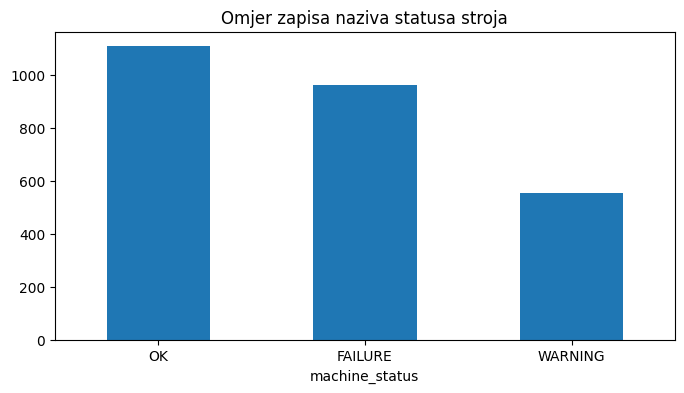

In [23]:
df['machine_status'].value_counts().plot(
    kind='bar',
    figsize=(8, 4),
    title='Omjer zapisa naziva statusa stroja'
)

plt.xticks(rotation=0)

In [24]:
df.duplicated().sum()

np.int64(25)

In [25]:
df = df.drop_duplicates()
df.shape

(2600, 15)

- 0   record_id                  2625 non-null   int64
- 1   machine_type               2625 non-null   str  
- 2   shift                      2625 non-null   str  
- 3   operator_level             2586 non-null   str  
- 4   maintenance_done_recently  2573 non-null   str  
- 5   temperature_c              2525 non-null   str  
- 6   pressure_bar               2551 non-null   str  
- 7   vibration_mm_s             2537 non-null   str  
- 8   current_a                  2566 non-null   str  
- 9   runtime_hours              2548 non-null   str  
- 10  humidity_pct               2563 non-null   str  
- 11  production_rate_units_h    2548 non-null   str  
- 12  defect_count_last_hour     2625 non-null   int64
- 13  days_since_maintenance     2625 non-null   int64
- 14  machine_status             2625 non-null   str  

In [47]:
numericke_kolone = [
    'temperature_c',
    'pressure_bar',
    'vibration_mm_s',
    'current_a',
    'runtime_hours',
    'humidity_pct',
    'production_rate_units_h',
    'defect_count_last_hour',
    'days_since_maintenance'
]

tekstualne_kolone = [
    'machine_type',
    'shift',
    'operator_level',
    'maintenance_done_recently',
    'machine_status'
]

In [62]:
def clean_numeric_column(series):
    cleaned = (
        series
        .astype('string')
        .str.strip()
        .str.replace(',', '.')
        .str.replace(' C', '')
        .str.replace(' bar', '')
        .str.replace(' mm/s', '')
        .str.replace(' A', '')
        .str.replace(' h', '')
        .str.replace(' %', '')
        .str.replace(' u/h', '')
    )
    # replace([' C',' bar',' mm/s',' A',' h','%','u/h'],'',regex=True) može se i ovako

    cleaned = cleaned.replace({
        '?': pd.NA,
        'unknown': pd.NA,
        '<NA>': pd.NA,
        'error': pd.NA
    })

    return pd.to_numeric(cleaned)

In [55]:
for column in numericke_kolone:
    df[column] = clean_numeric_column(df[column])

df[numericke_kolone].head(15)

,temperature_c,pressure_bar,vibration_mm_s,current_a,runtime_hours,humidity_pct,production_rate_units_h,defect_count_last_hour,days_since_maintenance
0,54.58,6.54,<NA>,10.34,643.80,46.80,121.90,0,14
1,74.41,8.11,4.76,20.90,828.40,59.90,92.80,3,23
2,67.69,10.16,5.82,24.87,785.10,28.00,66.80,2,69
3,73.82,8.72,1.88,15.91,"1,040.60",12.80,113.70,1,103
4,82.20,7.06,7.77,26.90,675.50,67.50,<NA>,2,13
5,80.29,7.76,6.73,24.64,225.70,52.80,111.70,5,49
6,62.67,6.05,6.44,29.50,"1,262.30",55.40,101.40,1,12
7,64.06,6.66,1.05,20.44,395.10,43.00,84.00,3,111
8,54.26,5.58,0.83,<NA>,443.50,71.70,116.40,0,107
9,74.83,4.83,0.59,16.71,305.50,40.90,85.50,2,26


In [56]:
df[numericke_kolone].dtypes

temperature_c              Float64
pressure_bar               Float64
vibration_mm_s             Float64
current_a                  Float64
runtime_hours              Float64
humidity_pct               Float64
production_rate_units_h    Float64
defect_count_last_hour       Int64
days_since_maintenance       Int64
dtype: object

In [60]:
def basic_text_clean(series):
    return (
        series
        .astype('string')
        .str.strip()
        .str.lower()
    )

In [67]:
df['machine_type'] = basic_text_clean(df['machine_type']).map({
    'cnc': 'CNC',
    'conveyor': 'Conveyor',
    'pump': 'Pump',
    'compressor': 'Compressor'
})

df['shift'] = basic_text_clean(df['shift']).map({
    'morning': 'Morning',
    'm': 'Morning',
    'aft': 'Afternoon',
    'afternoon': 'Afternoon',
    'a': 'Afternoon',
    'n': 'Night',
    'night': 'Night'
})

df['operator_level'] = basic_text_clean(df['operator_level']).map({
    'intermediate': 'Intermediate',
    'junior': 'Junior',
    'senior':'Senior',
    'mid':'Intermediate',
    'jr': 'Junior',
    'sr':'Senior'
})

df['maintenance_done_recently'] = basic_text_clean(df['maintenance_done_recently']).map({
    'no': 'No',
    'yes': 'Yes',
    '0': 'No',
    'n': 'No',
    'Y': 'Yes',
    '1': 'Yes'
})


In [68]:
df.head(25)

,record_id,machine_type,shift,operator_level,maintenance_done_recently,temperature_c,pressure_bar,vibration_mm_s,current_a,runtime_hours,humidity_pct,production_rate_units_h,defect_count_last_hour,days_since_maintenance,machine_status
0,100528,Conveyor,Morning,Intermediate,No,54.58,6.54,<NA>,10.34,643.80,46.80,121.90,0,14,OK
1,100739,Pump,Morning,Intermediate,Yes,74.41,8.11,4.76,20.90,828.40,59.90,92.80,3,23,FAILURE
2,100276,Pump,Morning,Junior,No,67.69,10.16,5.82,24.87,785.10,28.00,66.80,2,69,FAILURE
3,102058,Pump,Morning,Senior,NaN,73.82,8.72,1.88,15.91,"1,040.60",12.80,113.70,1,103,WARNING
4,102034,Pump,Morning,Intermediate,No,82.20,7.06,7.77,26.90,675.50,67.50,<NA>,2,13,FAILURE
5,102214,Pump,Night,Intermediate,Yes,80.29,7.76,6.73,24.64,225.70,52.80,111.70,5,49,WARNING
6,100359,Pump,Morning,Intermediate,No,62.67,6.05,6.44,29.50,"1,262.30",55.40,101.40,1,12,FAILURE
7,102576,Compressor,Morning,Intermediate,No,64.06,6.66,1.05,20.44,395.10,43.00,84.00,3,111,WARNING
8,101334,Conveyor,Morning,Junior,No,54.26,5.58,0.83,<NA>,443.50,71.70,116.40,0,107,OK
9,100255,CNC,Night,Senior,No,74.83,4.83,0.59,16.71,305.50,40.90,85.50,2,26,OK


In [69]:
df.info()

<class 'pandas.DataFrame'>
Index: 2600 entries, 0 to 2624
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   record_id                  2600 non-null   int64  
 1   machine_type               2600 non-null   str    
 2   shift                      2600 non-null   str    
 3   operator_level             2561 non-null   str    
 4   maintenance_done_recently  2461 non-null   str    
 5   temperature_c              2479 non-null   Float64
 6   pressure_bar               2505 non-null   Float64
 7   vibration_mm_s             2492 non-null   Float64
 8   current_a                  2518 non-null   Float64
 9   runtime_hours              2505 non-null   Float64
 10  humidity_pct               2518 non-null   Float64
 11  production_rate_units_h    2505 non-null   Float64
 12  defect_count_last_hour     2600 non-null   Int64  
 13  days_since_maintenance     2600 non-null   Int64  
 14  machine_

In [71]:
df.isna().sum()

record_id                      0
machine_type                   0
shift                          0
operator_level                39
maintenance_done_recently    139
temperature_c                121
pressure_bar                  95
vibration_mm_s               108
current_a                     82
runtime_hours                 95
humidity_pct                  82
production_rate_units_h       95
defect_count_last_hour         0
days_since_maintenance         0
machine_status                 0
dtype: int64

In [75]:
for column in tekstualne_kolone:
    mode_value = df[column].mode()[0]
    df[column] = df[column].fillna(mode_value)

In [76]:
for column in numericke_kolone:
    median_value = df[column].median()
    df[column] = df[column].fillna(median_value)

In [77]:
df.isna().sum()

record_id                    0
machine_type                 0
shift                        0
operator_level               0
maintenance_done_recently    0
temperature_c                0
pressure_bar                 0
vibration_mm_s               0
current_a                    0
runtime_hours                0
humidity_pct                 0
production_rate_units_h      0
defect_count_last_hour       0
days_since_maintenance       0
machine_status               0
dtype: int64

In [79]:
df.head()

,record_id,machine_type,shift,operator_level,maintenance_done_recently,temperature_c,pressure_bar,vibration_mm_s,current_a,runtime_hours,humidity_pct,production_rate_units_h,defect_count_last_hour,days_since_maintenance,machine_status
0,100528,Conveyor,Morning,Intermediate,No,54.58,6.54,2.70,10.34,643.80,46.80,121.90,0,14,OK
1,100739,Pump,Morning,Intermediate,Yes,74.41,8.11,4.76,20.90,828.40,59.90,92.80,3,23,FAILURE
2,100276,Pump,Morning,Junior,No,67.69,10.16,5.82,24.87,785.10,28.00,66.80,2,69,FAILURE
3,102058,Pump,Morning,Senior,No,73.82,8.72,1.88,15.91,"1,040.60",12.80,113.70,1,103,WARNING
4,102034,Pump,Morning,Intermediate,No,82.20,7.06,7.77,26.90,675.50,67.50,97.70,2,13,FAILURE


In [86]:
X = df.drop(columns=['record_id', 'machine_status', 'machine_type', 'shift', 'operator_level', 'maintenance_done_recently'])
y = df['machine_status']

In [87]:
X.head()

,temperature_c,pressure_bar,vibration_mm_s,current_a,runtime_hours,humidity_pct,production_rate_units_h,defect_count_last_hour,days_since_maintenance
0,54.58,6.54,2.70,10.34,643.80,46.80,121.90,0,14
1,74.41,8.11,4.76,20.90,828.40,59.90,92.80,3,23
2,67.69,10.16,5.82,24.87,785.10,28.00,66.80,2,69
3,73.82,8.72,1.88,15.91,"1,040.60",12.80,113.70,1,103
4,82.20,7.06,7.77,26.90,675.50,67.50,97.70,2,13


In [88]:
y.head()

0         OK
1    FAILURE
2    FAILURE
3    WARNING
4    FAILURE
Name: machine_status, dtype: str

In [104]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [105]:
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [106]:
y_pred_tree = tree_model.predict(X_test)
y_pred_tree[:10]

array(['FAILURE', 'WARNING', 'WARNING', 'FAILURE', 'WARNING', 'FAILURE',
       'WARNING', 'WARNING', 'FAILURE', 'OK'], dtype=object)

In [110]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_accuracy

0.6461538461538462

In [111]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [112]:
y_pred_knn = knn_model.predict(X_test)
y_pred_knn[:10]

array(['WARNING', 'WARNING', 'FAILURE', 'FAILURE', 'FAILURE', 'OK',
       'WARNING', 'OK', 'FAILURE', 'OK'], dtype=object)

In [113]:
knn_accuracy = accuracy_score(y_test, y_pred_tree)
knn_accuracy

0.6461538461538462